# EDA : Kings County, Jacob Phillips
![](https://images.unsplash.com/photo-1618890187352-8e9d6b96b948?q=80&w=3106&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D)

### The purpose of this project is to explore data around Kings County housing and use it to suggest property to satisfy the request of our client:
Jacob Phillips | Buyer

Unlimited Budget, 4+ bathrooms or smaller house nearby, big lot (tennis court & pool), golf, historic, no waterfront view. 


##### The process consisted of: 
1. Data preparation and exploration
2. Building hypotheses around correlations of data
3. Model diagnostics and visualising results (Done per hypothesis)
3. Building a suggestion portfolio

## Step 1: Data preparation and cleanup

In [178]:
# Importing datasets and conducting preliminary view of the data

import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

df = pd.read_csv("data/eda.csv")

df.info


<bound method DataFrame.info of                id  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
0      7129300520     3.000      1.000     1180.000  5650.000   1.000   
1      6414100192     3.000      2.250     2570.000  7242.000   2.000   
2      5631500400     2.000      1.000      770.000 10000.000   1.000   
3      2487200875     4.000      3.000     1960.000  5000.000   1.000   
4      1954400510     3.000      2.000     1680.000  8080.000   1.000   
...           ...       ...        ...          ...       ...     ...   
21592   263000018     3.000      2.500     1530.000  1131.000   3.000   
21593  6600060120     4.000      2.500     2310.000  5813.000   2.000   
21594  1523300141     2.000      0.750     1020.000  1350.000   2.000   
21595   291310100     3.000      2.500     1600.000  2388.000   2.000   
21596  1523300157     2.000      0.750     1020.000  1076.000   2.000   

       waterfront  view  condition  grade  ...  sqft_basement  yr_built  \
0             Na

In [179]:
df = pd.read_csv("data/eda.csv")
df.head()


,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3.000,1.000,1180.000,5650.000,1.000,NaN,0.000,3,7,...,0.000,1955,0.000,98178,47.511,-122.257,1340.000,5650.000,2014-10-13,221900.000
1,6414100192,3.000,2.250,2570.000,7242.000,2.000,0.000,0.000,3,7,...,400.000,1951,19910.000,98125,47.721,-122.319,1690.000,7639.000,2014-12-09,538000.000
2,5631500400,2.000,1.000,770.000,10000.000,1.000,0.000,0.000,3,6,...,0.000,1933,NaN,98028,47.738,-122.233,2720.000,8062.000,2015-02-25,180000.000
3,2487200875,4.000,3.000,1960.000,5000.000,1.000,0.000,0.000,5,7,...,910.000,1965,0.000,98136,47.521,-122.393,1360.000,5000.000,2014-12-09,604000.000
4,1954400510,3.000,2.000,1680.000,8080.000,1.000,0.000,0.000,3,8,...,0.000,1987,0.000,98074,47.617,-122.045,1800.000,7503.000,2015-02-18,510000.000


### Data cleanup 

In [180]:
# Convert bedrooms to integer (removes the .000 entirely)
df['bedrooms'] = df['bedrooms'].astype(int)
# Convert floors to integer (removes the .000 entirely)
df['floors'] = df['floors'].astype(int)



# Fill 0 instead of NaN to fix missing data 
df['yr_renovated'] = df['yr_renovated'].fillna(0)
df['waterfront'] = df['waterfront'].fillna(0)
df['sqft_basement'] = df['sqft_basement'].fillna(0)
df['view'] = df['view'].fillna(0)

# Convert waterfront and view to integer (removes the .000 entirely)
df['waterfront'] = df['waterfront'].astype(int)
df['view'] = df['view'].astype(int)

# Convert year renovated to integer + fix the mistake in format writing 
df["yr_renovated"] = df["yr_renovated"].apply(
    lambda x: x / 10 if x > 9999 else x
)
df['yr_renovated'] = df['yr_renovated'].astype(int)

# Round to .xx and only show .xx for the whole dataframe
df = df.round(2)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

df.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3,1.00,1180.00,5650.00,1,0,0,3,7,...,0.00,1955,0,98178,47.51,-122.26,1340.00,5650.00,2014-10-13,221900.00
1,6414100192,3,2.25,2570.00,7242.00,2,0,0,3,7,...,400.00,1951,1991,98125,47.72,-122.32,1690.00,7639.00,2014-12-09,538000.00
2,5631500400,2,1.00,770.00,10000.00,1,0,0,3,6,...,0.00,1933,0,98028,47.74,-122.23,2720.00,8062.00,2015-02-25,180000.00
3,2487200875,4,3.00,1960.00,5000.00,1,0,0,5,7,...,910.00,1965,0,98136,47.52,-122.39,1360.00,5000.00,2014-12-09,604000.00
4,1954400510,3,2.00,1680.00,8080.00,1,0,0,3,8,...,0.00,1987,0,98074,47.62,-122.04,1800.00,7503.00,2015-02-18,510000.00


In [181]:
df.describe()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price
count,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00
mean,4580474287.77,3.37,2.12,2080.32,15099.41,1.45,0.01,0.23,3.41,7.66,1788.60,285.75,1971.00,68.76,98077.95,47.56,-122.21,1986.62,12758.28,540296.57
std,2876735715.75,0.93,0.77,918.11,41412.64,0.55,0.08,0.76,0.65,1.17,827.76,439.82,29.38,364.04,53.51,0.14,0.14,685.23,27274.44,367368.14
min,1000102.00,1.00,0.50,370.00,520.00,1.00,0.00,0.00,1.00,3.00,370.00,0.00,1900.00,0.00,98001.00,47.16,-122.52,399.00,651.00,78000.00
25%,2123049175.00,3.00,1.75,1430.00,5040.00,1.00,0.00,0.00,3.00,7.00,1190.00,0.00,1951.00,0.00,98033.00,47.47,-122.33,1490.00,5100.00,322000.00
50%,3904930410.00,3.00,2.25,1910.00,7618.00,1.00,0.00,0.00,3.00,7.00,1560.00,0.00,1975.00,0.00,98065.00,47.57,-122.23,1840.00,7620.00,450000.00
75%,7308900490.00,4.00,2.50,2550.00,10685.00,2.00,0.00,0.00,4.00,8.00,2210.00,550.00,1997.00,0.00,98118.00,47.68,-122.12,2360.00,10083.00,645000.00
max,9900000190.00,33.00,8.00,13540.00,1651359.00,3.00,1.00,4.00,5.00,13.00,9410.00,4820.00,2015.00,2015.00,98199.00,47.78,-121.32,6210.00,871200.00,7700000.00


#### Lets's plot all the data to get the better understanding of the distribution

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>,
        <Axes: title={'center': 'sqft_living'}>],
       [<Axes: title={'center': 'sqft_lot'}>,
        <Axes: title={'center': 'floors'}>,
        <Axes: title={'center': 'waterfront'}>,
        <Axes: title={'center': 'view'}>],
       [<Axes: title={'center': 'condition'}>,
        <Axes: title={'center': 'grade'}>,
        <Axes: title={'center': 'sqft_above'}>,
        <Axes: title={'center': 'sqft_basement'}>],
       [<Axes: title={'center': 'yr_built'}>,
        <Axes: title={'center': 'yr_renovated'}>,
        <Axes: title={'center': 'zipcode'}>,
        <Axes: title={'center': 'lat'}>],
       [<Axes: title={'center': 'long'}>,
        <Axes: title={'center': 'sqft_living15'}>,
        <Axes: title={'center': 'sqft_lot15'}>,
        <Axes: title={'center': 'price'}>]], dtype=object)

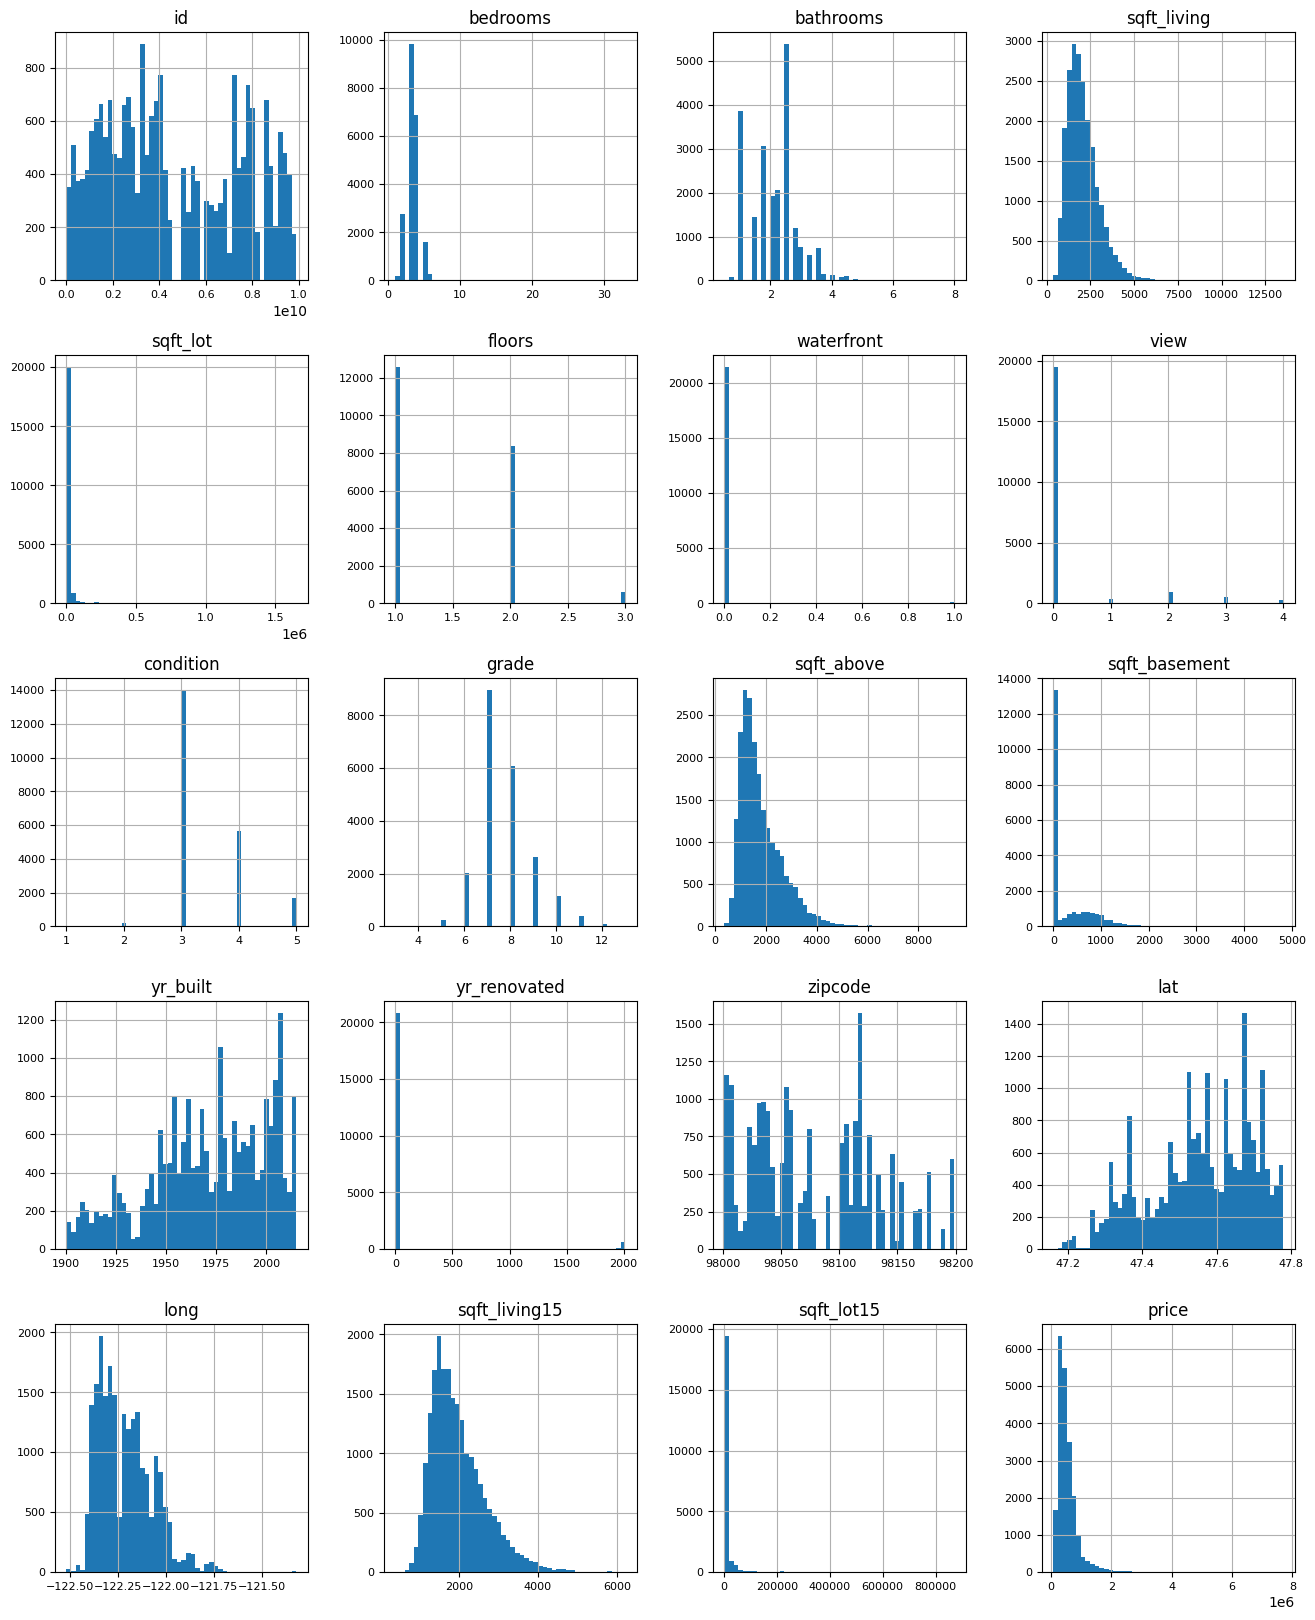

In [182]:
df.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8)

#### Finding the features most correlated with the price of the houses 

In [183]:
df_num = df.select_dtypes(include = ['float64', 'int64'])

df_num = df_num.corr()['price'][:-1] # -1 because the latest row is SalePrice
golden_features_list = df_num[abs(df_num) > 0.5].sort_values(ascending=False)
print("There is {} strongly correlated values with Sale Price:\n{}".format(len(golden_features_list), golden_features_list))

There is 5 strongly correlated values with Sale Price:
sqft_living     0.70
grade           0.67
sqft_above      0.61
sqft_living15   0.59
bathrooms       0.53
Name: price, dtype: float64


#### Building Scatter-plot of the 5 most correlated ones

['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'price']


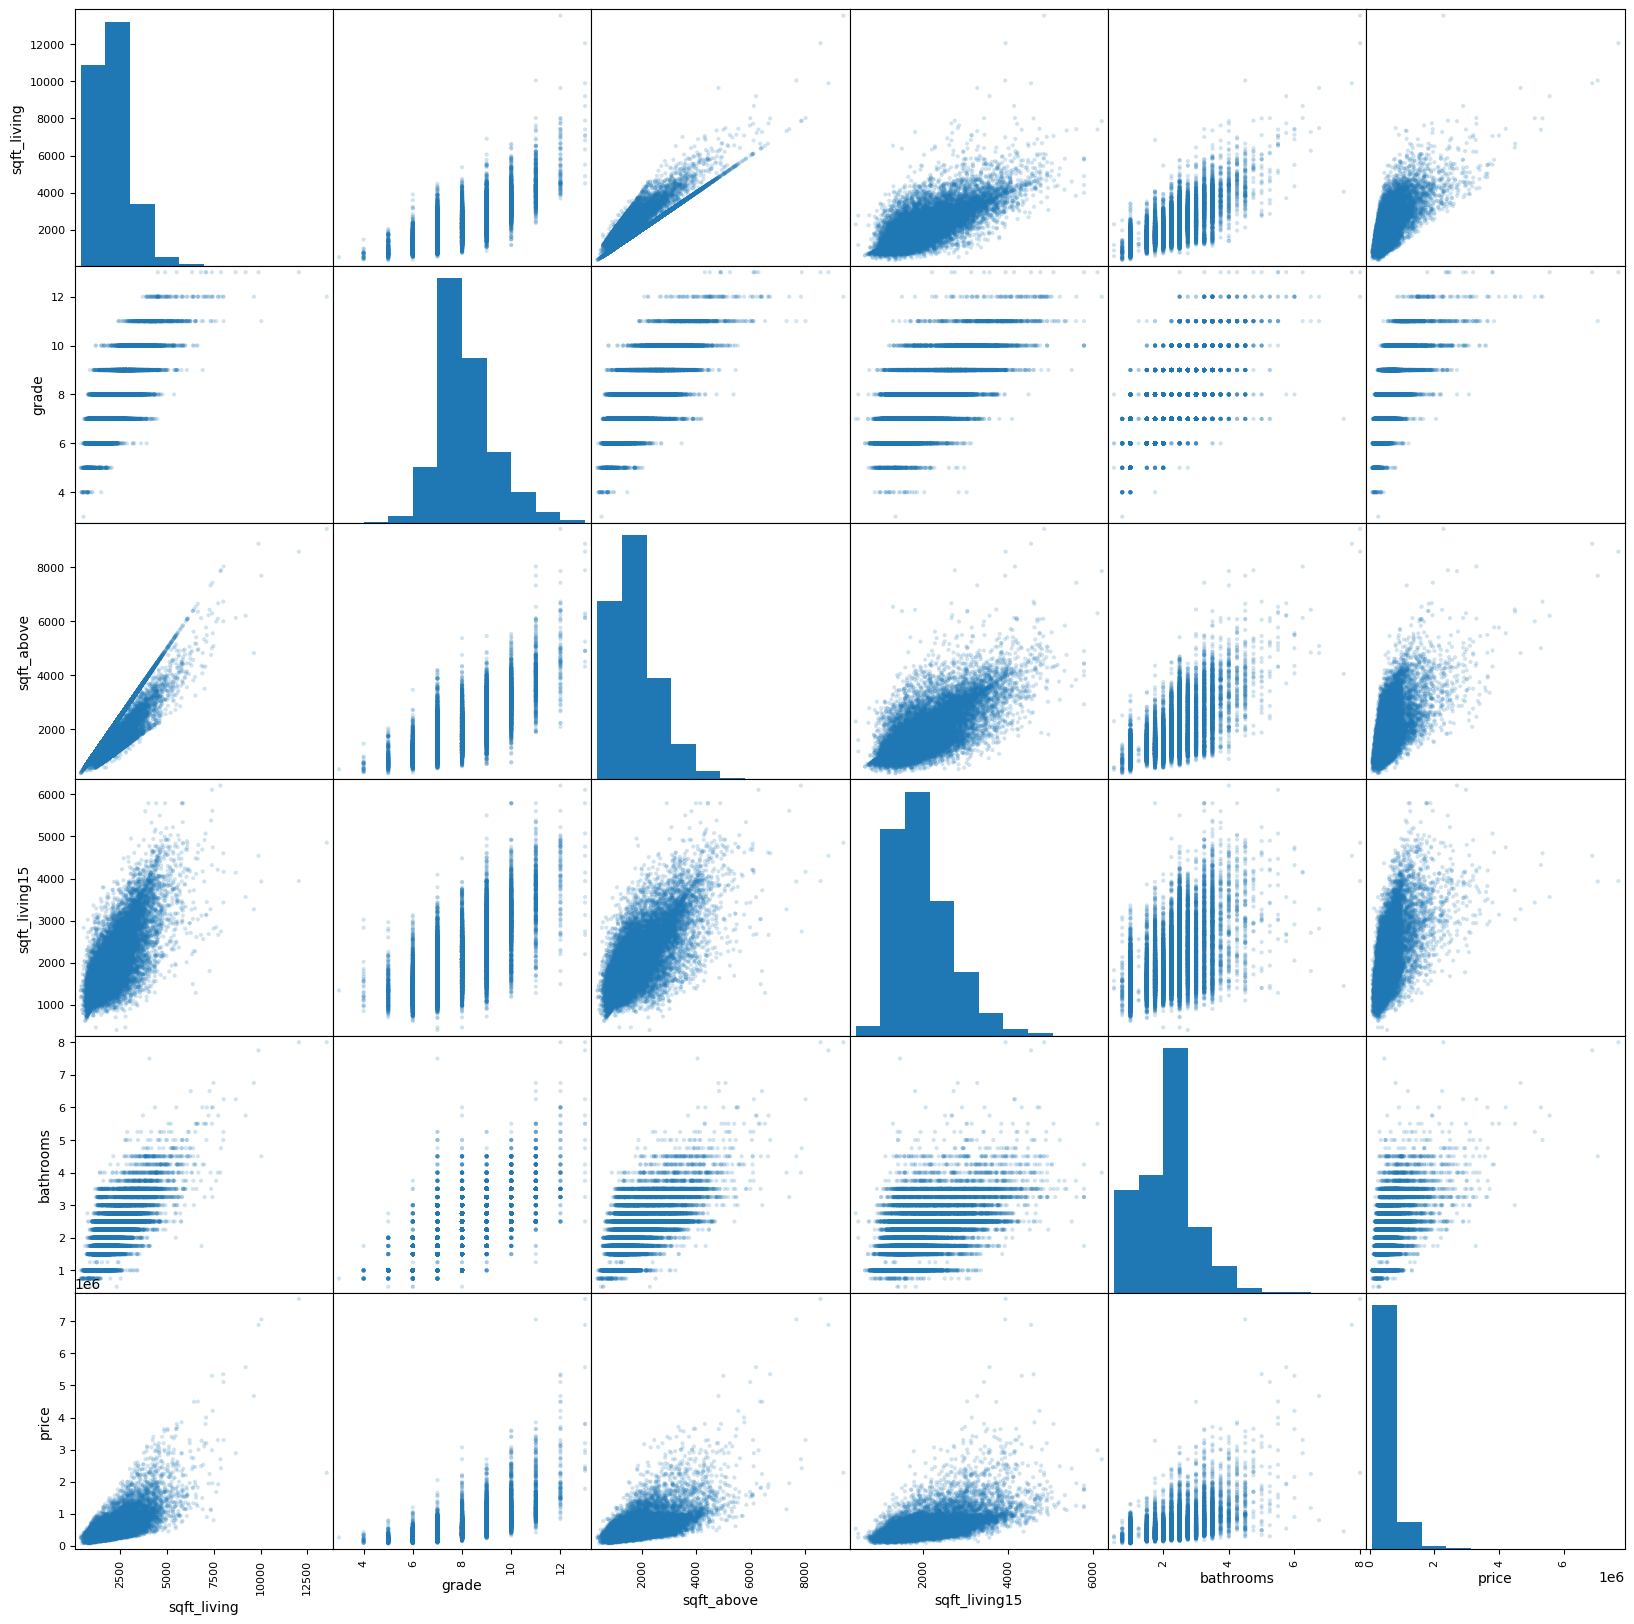

In [184]:
from pandas.plotting import scatter_matrix

df_num = df.select_dtypes(include=['float64', 'int64'])
print(df_num.columns.tolist())
cols = golden_features_list.index.tolist() + ['price']
scatter_matrix(df_num[cols], figsize=(20, 20), alpha=0.2, diagonal='hist')
plt.show()




-------------



### CLARIFICATIONS ON VARIABLES
Some variables in the original dataframes (column headers) are ambiguous, so ahead of a correlation heatmap of the variables, i sought clarifications online. Below are the column headers that were not immediately understandable and their meaning:
- floors	    Number of floors [pending clarification on what exactly 1.5 floors entails] 
- view	        An index from 0 to 4 of how good the view of the property was - OK CLEAR - LARGER BETTER
- condition	    Condition of the house, ranked from 1 to 5 - OK, ASSUMED HIGHER IS BETTER
- grade	        Classification by construction quality which refers to the types of materials used and the quality of workmanship. Buildings of better quality (higher grade) cost more to build per unit of measure and command higher value. - OK HIGHER IS BETTER
- squft_liv15	Average size of interior housing living space for the closest 15 houses, in square feet - OK
- squft_lot15	Average size of land lots for the closest 15 houses, in square feet - OK 

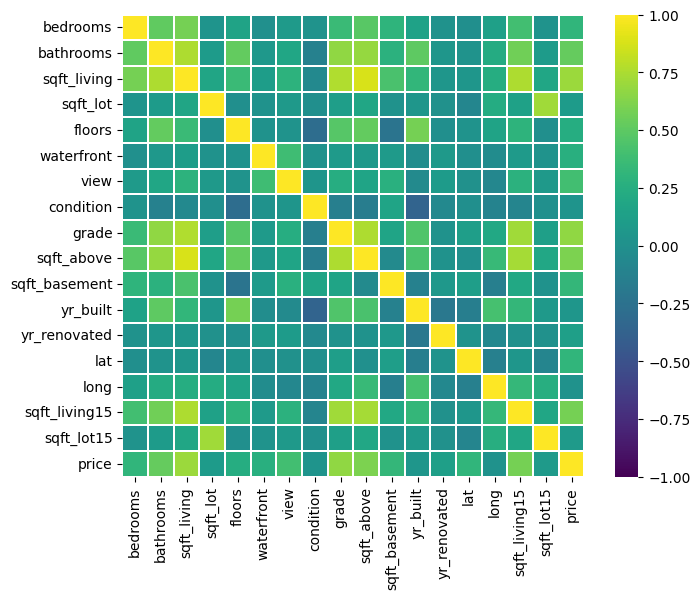

In [207]:
import seaborn as sns

#First an all-in only colors to see if some variable can be excluded for better exploration of the correlations.
# We already exclude id and zipcode since the numbers are a characteristic based on the location 
# or database ordering.
corr = df.select_dtypes(include=['float64', 'int64']).drop(['id', 'zipcode'], axis=1).corr()
plt.figure(figsize=(8, 6))

sns.heatmap(corr[(corr >= 0) | (corr <= 0)], 
    cmap='viridis', vmax=1.0, vmin=-1.0, linewidths=0.1,
    square=True);

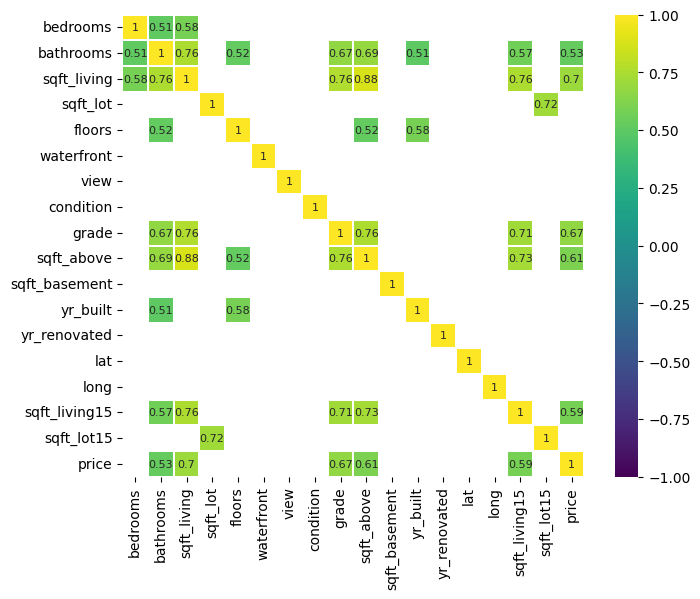

In [208]:
#Let's be more selective and only show the correlations that are above 0.5 or below -0.4 to see if we can find some interesting relationships between the features. 
corr = df.select_dtypes(include=['float64', 'int64']).drop(['id', 'zipcode'], axis=1).corr()
plt.figure(figsize=(8, 6))

sns.heatmap(corr[(corr >= 0.5) | (corr <= -0.4)], 
    cmap='viridis', vmax=1.0, vmin=-1.0, linewidths=0.1,
    annot=True, annot_kws={"size": 8}, square=True);

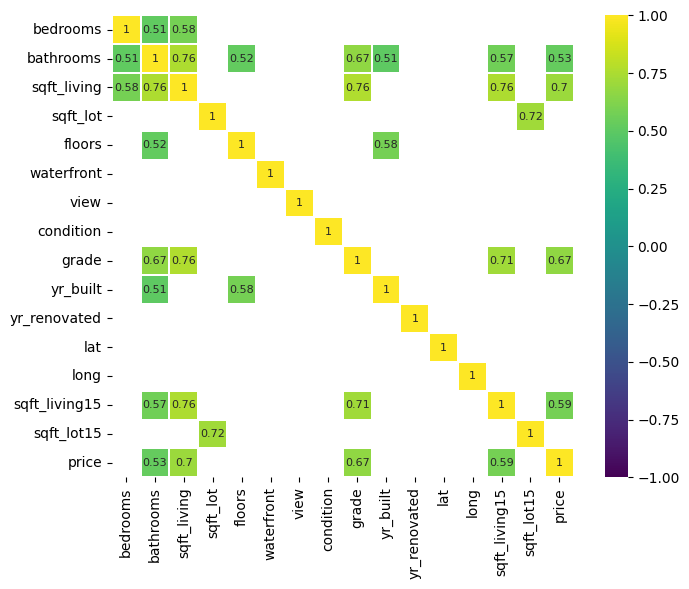

In [209]:
# we can exclude redundant statistics (sqft_above/basement are well represented by Sqft_living).  
# Grade is also correlated with sqft_lliving, but we rather leave it in because it can be an important 
# later filter for our customer JACOB that has unlimited budget. 
corr = df.select_dtypes(include=['float64', 'int64']).drop(['id', 'zipcode', 'sqft_above', 'sqft_basement'], axis=1).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr[(corr >= 0.5) | (corr <= -0.4)], 
    cmap='viridis', vmax=1.0, vmin=-1.0, linewidths=0.1,
    annot=True, annot_kws={"size": 8}, square=True);

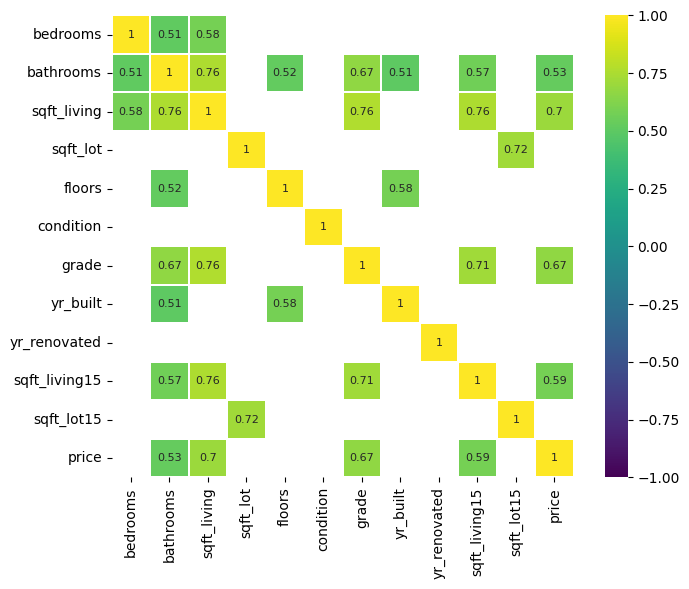

In [210]:
import seaborn as sns
# Finally, some variables are of a nature that makes statistical analysis wonky. 
# Let's try one last chart excluding the empty rows:
# - waterfront (binary)
# - view (category based, subjective and integer)
# - lat/long (geo, the correlations are meaningless) better filtered by hand-picked zipcodes
corr = df.select_dtypes(include=['float64', 'int64']).drop(['id', 'zipcode', 'sqft_above', 'sqft_basement', 'waterfront', 'view', 'lat', 'long'], axis=1).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr[(corr >= 0.5) | (corr <= -0.4)], 
    cmap='viridis', vmax=1.0, vmin=-1.0, linewidths=0.1,
    annot=True, annot_kws={"size": 8}, square=True);

## Step 2: Building Hypotheses

While analysing data, we came up with 3 insights around Jacobs iterests

### Hypotheses

1. GEO - ZIP codes with waterfront will have higher average price per sqft than those away from the water, within city limits.

Counters - port city, cold, humidity can be a negative - can be that places in high altitude neighborhoods fetch better prices.

2. Amount of bathrooms correlates with how historical the area is.

3. Year built will correlate with value, older non-renovated houses will have lower persqft value.
[This may also be a curve, as some classic houses may be in classic locations instead of edge of the city.]

### Hypothesis 1

GEO - ZIP codes with waterfront will have higher average price per sqft than those away from the water, within city limits.

------

Counters - port city, cold, humidity can be a negative - can be that places in high altitude neighborhoods fetch better prices.

We start by introducing new metric: PRICE PER SQFT

In [214]:
# Introducing PRICE PER SQFT Metric
df['px_per_sqft'] = df['price'] / df['sqft_living']
df.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,px_per_sqft
0,7129300520,3,1.00,1180.00,5650.00,1,0,0,3,7,...,1955,0,98178,47.51,-122.26,1340.00,5650.00,2014-10-13,221900.00,188.05
1,6414100192,3,2.25,2570.00,7242.00,2,0,0,3,7,...,1951,1991,98125,47.72,-122.32,1690.00,7639.00,2014-12-09,538000.00,209.34
2,5631500400,2,1.00,770.00,10000.00,1,0,0,3,6,...,1933,0,98028,47.74,-122.23,2720.00,8062.00,2015-02-25,180000.00,233.77
3,2487200875,4,3.00,1960.00,5000.00,1,0,0,5,7,...,1965,0,98136,47.52,-122.39,1360.00,5000.00,2014-12-09,604000.00,308.16
4,1954400510,3,2.00,1680.00,8080.00,1,0,0,3,8,...,1987,0,98074,47.62,-122.04,1800.00,7503.00,2015-02-18,510000.00,303.57


Now calculate the avg px_per_sqft for these types of houses (separate table): 
- no waterfront, no view
- only waterfront
- only view (any and per level 1-4)
- both waterfront and view_any

In [215]:
# filters and means
results = {
    'no_waterfront_no_view': df[(df['waterfront'] == 0) & (df['view'] == 0)]['px_per_sqft'].mean(),
    'only_waterfront':       df[(df['waterfront'] == 1) & (df['view'] == 0)]['px_per_sqft'].mean(),
    'only_view_any':         df[(df['waterfront'] == 0) & (df['view'] > 0)]['px_per_sqft'].mean(),
    'only_view1':         df[(df['waterfront'] == 0) & (df['view'] == 1)]['px_per_sqft'].mean(),
    'only_view2':         df[(df['waterfront'] == 0) & (df['view'] == 2)]['px_per_sqft'].mean(),
    'only_view3':         df[(df['waterfront'] == 0) & (df['view'] == 3)]['px_per_sqft'].mean(),
    'only_view4':         df[(df['waterfront'] == 0) & (df['view'] == 4)]['px_per_sqft'].mean(),
    'both_waterfront_view_any':                  df[(df['waterfront'] == 1) & (df['view'] > 0)]['px_per_sqft'].mean(),
}

pd.Series(results)

no_waterfront_no_view      256.89
only_waterfront            717.19
only_view_any              317.55
only_view1                 320.05
only_view2                 303.18
only_view3                 318.43
only_view4                 381.42
both_waterfront_view_any   511.59
dtype: float64

This concludes that waterfront adds the largest value. The influence in view over pricing is mixed, probably unreliable or inconsistent view 'grades' attributed to the houses by different evaluators. view 4 is the highest, but the view 1 being higher than view 2 points to that inconsistency, and there is a concrete possibility that people inputting data consider view a binary yes/no 1/0 type entry and mess-up the statistics. 
Somewhat surprisingly, the view+waterfront average is not higher than just waterfront - can be explained by the fact that most evaluators consider view associated with altitude which makes a good view mutally exlcusive to waterfront. 

### Hypothesis 2

Amount of bathrooms correlates with how historical the area is.

------

Here we start by defining what historical area metric is — it's an average year of housing built. The lower such average is — more historical the zipcode area is. 

Therefore we will be grouping zipcodes by the average year of housing built, then sort and compare them further. 

Let's start with viewing the general picture if this metric

#### Average age of built per zipcode

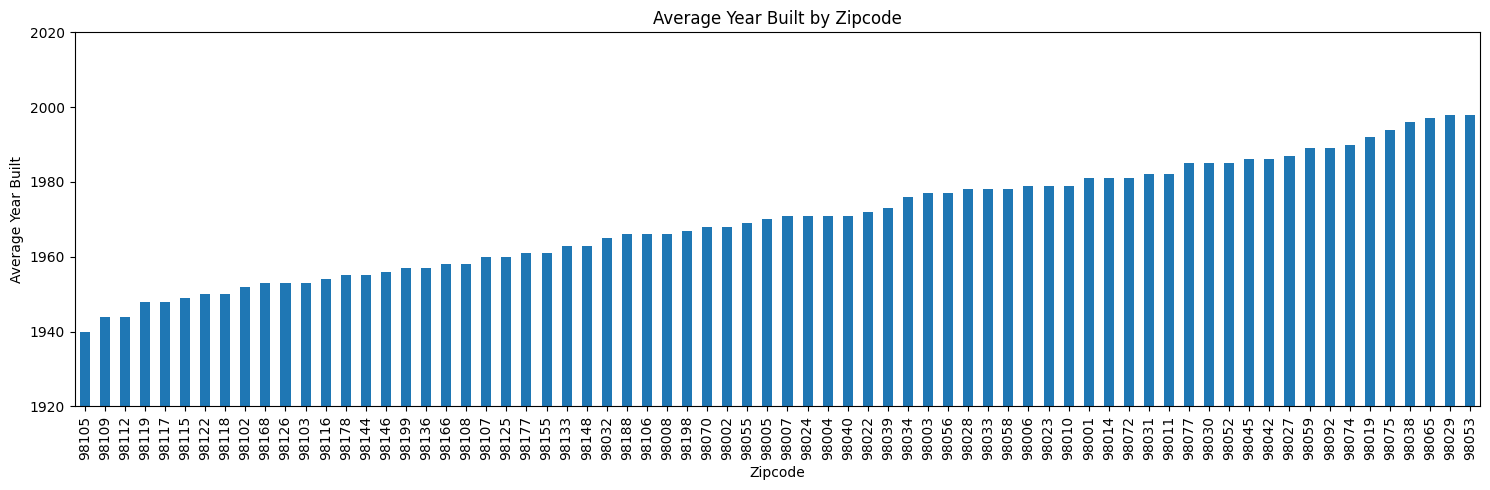

In [185]:
# Build a histogram to visualize this metric now

df_historical_area = df.groupby('zipcode')['yr_built'].mean().sort_values(ascending=True).round().astype(int)
df_historical_area.plot(kind='bar', figsize=(15, 5))
plt.xlabel('Zipcode')
plt.ylabel('Average Year Built')
plt.title('Average Year Built by Zipcode')
plt.tight_layout()
plt.ylim(1920, 2020)
plt.show()

#### Organized search for house locations that satisfy being historic and that have a golf course nearby

There are around 30 golf courses in King County, WA. A raw list of golf courses and their locations (coordinates or zip codes) will be not an effective filter since among the requirements, the buyer also wants a house that is in a historic area. Most golf courses will be in the suburbs. 

For maximal effectiveness in the search, we can narrow down the areas that are historic, and that have a nearby golf course.

The final data to be used as filter, is a list of zip codes that satisfy both conditions. That ZIP code can be used directly as a filter to the dataframe. 

Rather than Data Engineering, this is best done via searches in the internet and with AI tools.

An initial search via AI provides these zip codes with Golf Courses, that are located in districts that can be characterized as historic. The qualification as 'historic' is fuzzy and subject to interpretation - like having historic landmarks for example, and not a part of an 'official' historic-zipcode list. 

In [186]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

In [187]:
# add the commands here to show the contents of king_county_historic_golf_zips.csv
df_golfzips = pd.read_csv("king_county_historic_golf_zips.csv")
df_golfzips.head(14)

,zipcode,area_name,golf_course_name,why_historic
0,98118,"Columbia City, Seattle",Bill Wright Golf Complex (Jefferson Park),One of Seattle's eight officially designated h...
1,98144,"Mount Baker, Seattle",Bill Wright Golf Complex (Jefferson Park),Olmsted-planned early-20th-century streetcar n...
2,98108,"Beacon Hill, Seattle",Bill Wright Golf Complex (Jefferson Park),Contains the Olmsted Brothers-designed Jeffers...
3,98107,"Ballard, Seattle",Interbay Golf Center,Ballard Avenue Historic District is on the Nat...
4,98116,West Seattle (Admiral/Alki),West Seattle Golf Course,"Historic Admiral district and Alki Point, site..."
5,98126,West Seattle (Golf/Genesee),West Seattle Golf Course,Adjacent ZIP containing the municipal course (...
6,98125,Maple Leaf / North Seattle,Jackson Park Golf Course,Older north-Seattle housing stock near the his...
7,98065,Snoqualmie,Mount Si Golf Course,Historic downtown Snoqualmie and Snoqualmie Fa...
8,98022,Enumclaw,Enumclaw Golf Course,Historic early-1900s small-town downtown found...
9,98010,Black Diamond,"Lake Wilderness Golf Course (Maple Valley, 98038)",National Register-listed former coal-mining to...


#### Comparing zipcodes from both groups

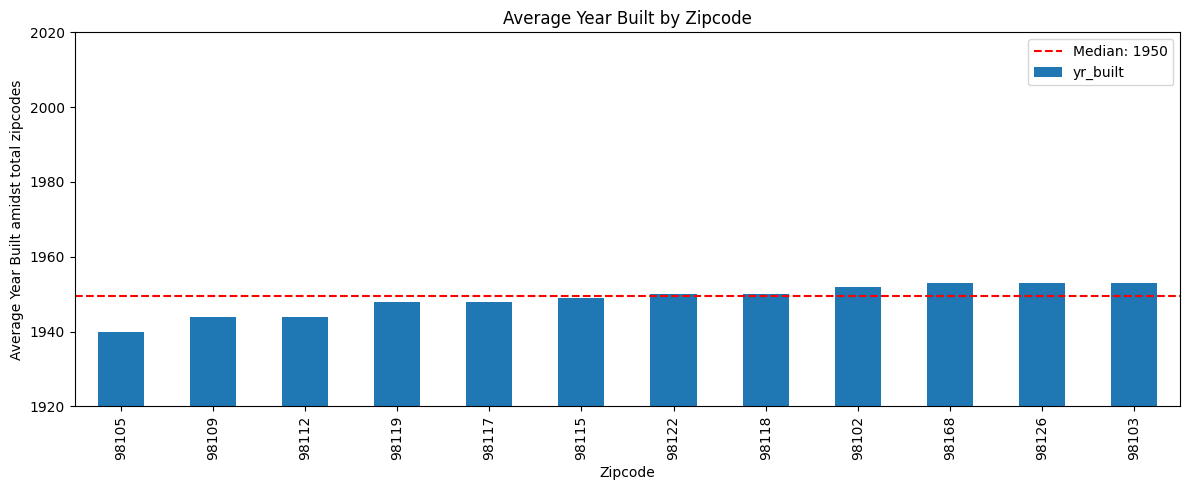

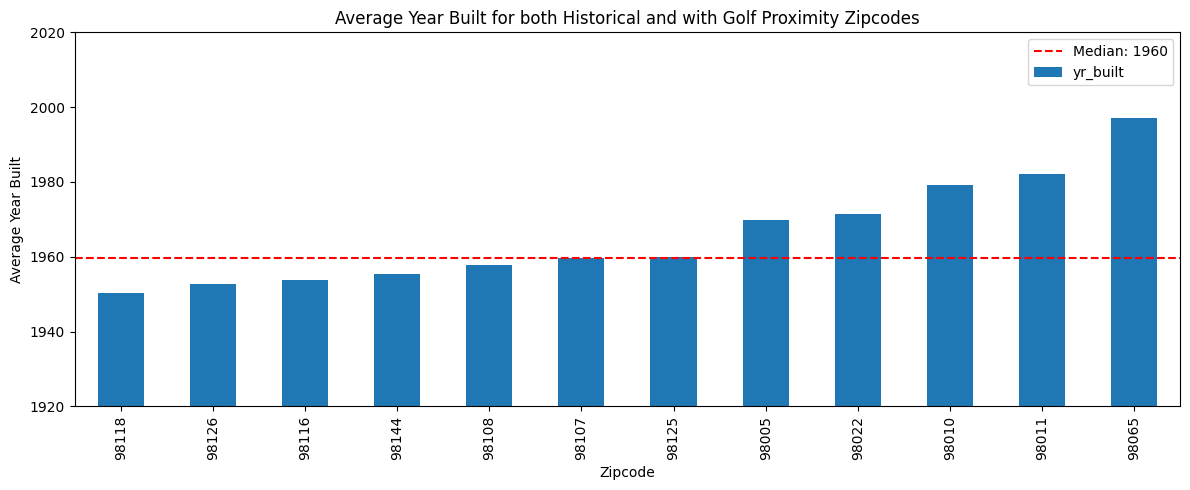

In [188]:
df_historical_area.head(12).plot(kind='bar', figsize=(12, 5))
plt.xlabel('Zipcode')
plt.ylabel('Average Year Built amidst total zipcodes')
plt.title('Average Year Built by Zipcode')
plt.tight_layout()
plt.ylim(1920, 2020)
plt.axhline(df_historical_area.head(12).median(), color='red', linestyle='--', label=f'Median: {df_historical_area.head(12).median():.0f}')
plt.legend()
plt.show()


# Now the chart only for those zipcodes that are in golfzipz
df_historical_golf = set(df_golfzips['zipcode']) & set(df_historical_area.index)

df_intersection = df[df['zipcode'].isin(df_historical_golf)].groupby('zipcode')['yr_built'].mean().sort_values(ascending=True)
df_intersection.plot(kind='bar', figsize=(12, 5))
plt.xlabel('Zipcode')
plt.ylabel('Average Year Built')
plt.title('Average Year Built for both Historical and with Golf Proximity Zipcodes')
plt.tight_layout()
plt.ylim(1920, 2020)
plt.axhline(df_intersection.median(), color='red', linestyle='--', label=f'Median: {df_intersection.median():.0f}')
plt.legend()
plt.show()








You can see that having a golf court in proximity slightly influences how historical the area is. 

#### Bathroom count correlation

In [189]:
# Now build a chart showing correlation between avg bathrooms and avg year built per area
df_zip = df.groupby('zipcode').agg(avg_bathrooms=('bathrooms', 'mean'), avg_yr_built=('yr_built', 'mean'))
Q1 = df_zip['avg_bathrooms'].quantile(0.25)
Q3 = df_zip['avg_bathrooms'].quantile(0.75)
IQR = Q3 - Q1

df_zip_clean = df_zip[(df_zip['avg_bathrooms'] >= Q1 - 1.5 * IQR) & 
                       (df_zip['avg_bathrooms'] <= Q3 + 1.5 * IQR)]

print(f"Correlation between avg bathrooms and avg year built per area: {df_zip_clean['avg_yr_built'].corr(df_zip_clean['avg_bathrooms']):.2f}")

# The trend exists (newer areas have more bathrooms) but it's not a reliable predictor on its own.


df_noreno = df[df['yr_renovated'] == 0]

df_zip_noreno = df_noreno.groupby('zipcode').agg(avg_bathrooms=('bathrooms', 'mean'), avg_yr_built=('yr_built', 'mean'))

Q1 = df_zip_noreno['avg_bathrooms'].quantile(0.25)
Q3 = df_zip_noreno['avg_bathrooms'].quantile(0.75)
IQR = Q3 - Q1

df_zip_noreno_clean = df_zip_noreno[(df_zip_noreno['avg_bathrooms'] >= Q1 - 1.5 * IQR) & 
                                     (df_zip_noreno['avg_bathrooms'] <= Q3 + 1.5 * IQR)]

print(f"without renovation: {df_zip_noreno_clean['avg_yr_built'].corr(df_zip_noreno_clean['avg_bathrooms']):.2f}")



df_reno = df[df['yr_renovated'] != 0]

df_zip_reno = df_reno.groupby('zipcode').agg(avg_bathrooms=('bathrooms', 'mean'), avg_yr_built=('yr_built', 'mean'))

Q1 = df_zip_reno['avg_bathrooms'].quantile(0.25)
Q3 = df_zip_reno['avg_bathrooms'].quantile(0.75)
IQR = Q3 - Q1

df_zip_reno_clean = df_zip_reno[(df_zip_reno['avg_bathrooms'] >= Q1 - 1.5 * IQR) & 
                                     (df_zip_reno['avg_bathrooms'] <= Q3 + 1.5 * IQR)]

print(f"with renovation: {df_zip_reno_clean['avg_yr_built'].corr(df_zip_reno_clean['avg_bathrooms']):.2f}")






Correlation between avg bathrooms and avg year built per area: 0.58
without renovation: 0.63
with renovation: 0.17




No renovations housing is moderate-to-strong positive correlation (0.63) — stronger than the full dataset (0.58) and much stronger than non-renovated houses (0.17).

This confirms that renovations are driving the relationship: renovated older homes tend to have more bathrooms added, pushing the correlation up.

It's also interesting to see that there's a dip for the timeframe of 1960-1970, let's investigate that

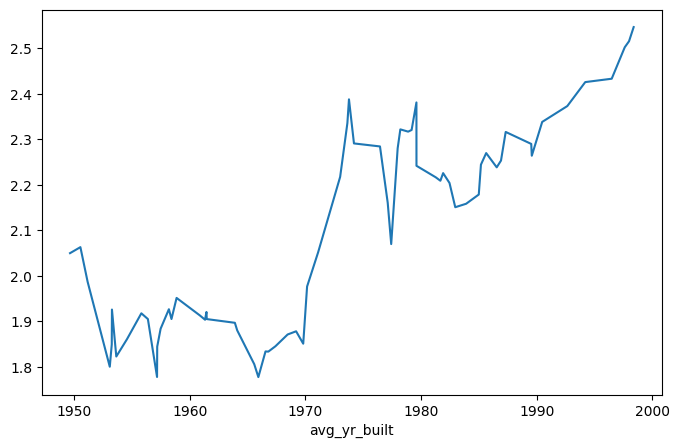

avg_bathrooms      1.43
avg_yr_built    1952.72
Name: 98168, dtype: float64


In [190]:
# Rolling average — smooths the scatter to visually find the dip edges

df_zip_noreno.sort_values('avg_yr_built').set_index('avg_yr_built')['avg_bathrooms'].rolling(5).mean().plot()
plt.show()

# Find the local minimum — the bottom of the dip

df_sorted = df_zip_clean.sort_values('avg_yr_built')
min_idx = df_sorted['avg_bathrooms'].idxmin()
print(df_sorted.loc[min_idx])


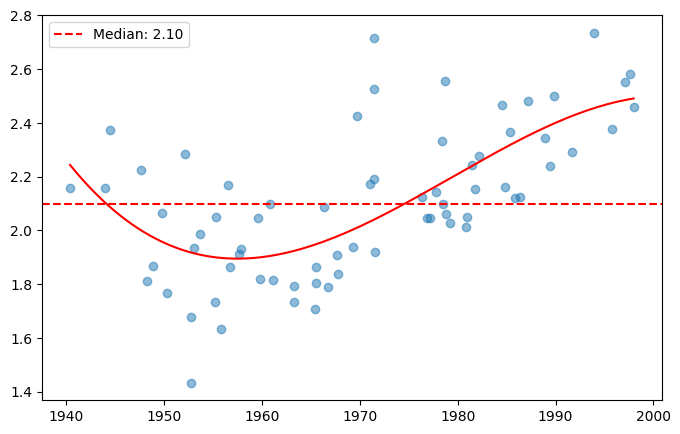

Dip bottom: 1953
Dip start: 1944
Dip end: 1989


In [191]:

#Polynomial regression — fits a curve and finds where it drops/rises

import numpy as np

x = df_zip_clean['avg_yr_built']
y = df_zip_clean['avg_bathrooms']

coeffs = np.polyfit(x, y, deg=3)
poly = np.poly1d(coeffs)

x_range = np.linspace(x.min(), x.max(), 300)
plt.scatter(x, y, alpha=0.5)
plt.plot(x_range, poly(x_range), color='red')
plt.axhline(df_zip_clean['avg_bathrooms'].median(), color='red', linestyle='--', label=f'Median: {df_zip_clean["avg_bathrooms"].median():.2f}')
plt.legend()
plt.show()


df_sorted = df_zip_clean.sort_values('avg_yr_built').reset_index()
rolling = df_sorted['avg_bathrooms'].rolling(5, center=True).mean()

# Find the bottom of the dip
min_idx = rolling.idxmin()
print(f"Dip bottom: {df_sorted.loc[min_idx, 'avg_yr_built']:.0f}")

# Find where it starts dropping and starts recovering
threshold = rolling.max() * 0.95  # 5% below peak = entering dip
dip_region = df_sorted[rolling < threshold]
print(f"Dip start: {dip_region['avg_yr_built'].min():.0f}")
print(f"Dip end: {dip_region['avg_yr_built'].max():.0f}")


As an interesting conclusion, we can tell that the houses built 1944 – 1989 tend to have less bathrooms specifically, which might be connected f.e. with the type of buildings built and the economy conditions (judging solely from the 1944-70s)  

#### CONCLUSION

While there is some correlation, it's not enough to build up on it. 
However more nuanced data, including abscense of innovation and a dip in bathroom count within 1944-1980s (peak 1953) might give insights on the type of buildings constructed and potentially wealth of the property. 

### Hypothesis 3

Year built will correlate with value, older houses will have lower price per sqft.  (USD/square foot)

------

Here we start by reviewing metric defined earlier in the new context

In [216]:
# now let's test house age (renovated or not) versus the px-per-sqft
# filters and means
results = {
    'overall':       df['px_per_sqft'].corr(df['yr_built']),
    'not_renovated': df[df['yr_renovated'] == 0]['px_per_sqft'].corr(df[df['yr_renovated'] == 0]['yr_built']),
    'renovated':     df[df['yr_renovated'] > 0]['px_per_sqft'].corr(df[df['yr_renovated'] > 0]['yr_built']),
}

pd.Series(results)


overall         -0.29
not_renovated   -0.29
renovated       -0.06
dtype: float64

Now building the scatter plot for correlation.

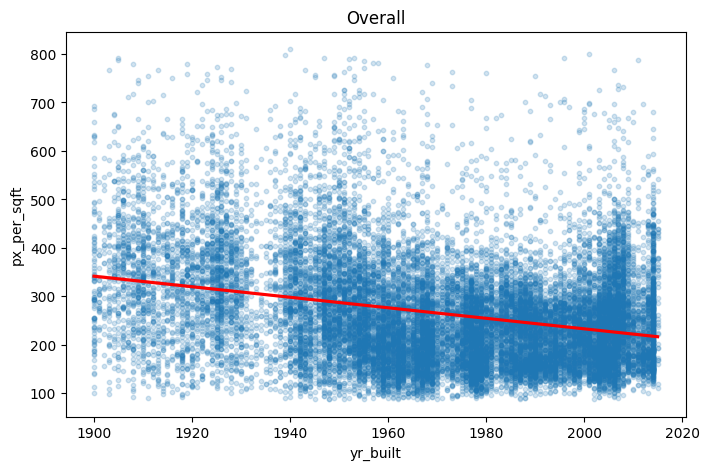

In [217]:
# Overall
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=df, x='yr_built', y='px_per_sqft', ax=ax,
            scatter_kws={'alpha': 0.2, 's': 10}, line_kws={'color': 'red'})
ax.set_title('Overall')
plt.show()

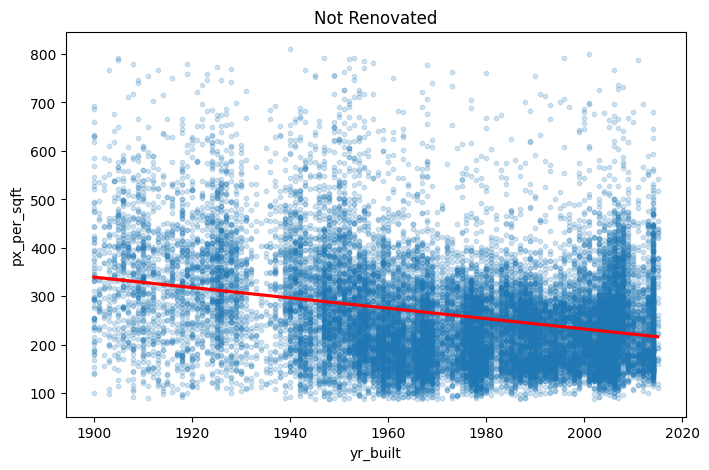

In [218]:
# Not Renovated
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=df[df['yr_renovated'] == 0], x='yr_built', y='px_per_sqft', ax=ax,
            scatter_kws={'alpha': 0.2, 's': 10}, line_kws={'color': 'red'})
ax.set_title('Not Renovated')
plt.show()

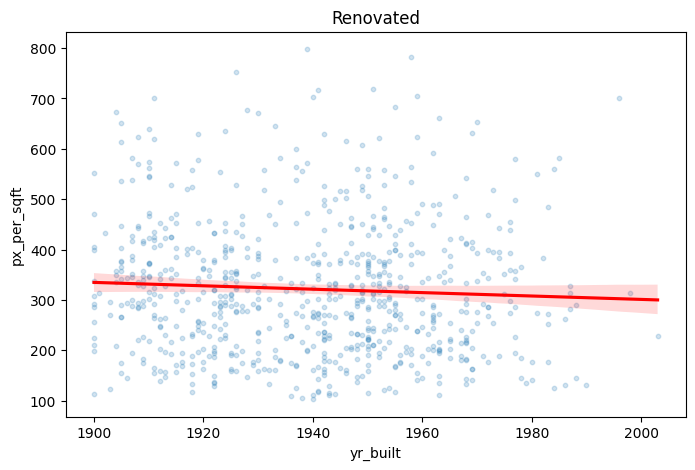

In [219]:
# Renovated
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=df[df['yr_renovated'] > 0], x='yr_built', y='px_per_sqft', ax=ax,
            scatter_kws={'alpha': 0.2, 's': 10}, line_kws={'color': 'red'})
ax.set_title('Renovated')
plt.show()

#### OBSERVATIONS - NOT CONFIRMED
A concrete possibility was a positive correlation, with newer houses commanding better prices: not the case.
Many potential explanations, hard to prove with the data available, among which we think are most likely:
 - Older houses were built in currently premium locations: historic, central, landmarks. Newer houses are suburban and remote, and less price dense.
 - Renovations have little effect - the ‘bones’ of the house dictate more of the value density. 
 - There is a case to be made that the variable grade (if reliably imputed) will be higher for older houses.


## Step 4: Building the suggestions portfolio


#### Working through filtering out historical areas first, then comparing with other requests

In [211]:
# Let's pick houses older than 1920 and form a dataframe with them

df_historical = df[df['yr_built'] < 1920]
df_historical.head()
df_historical.describe()

# WOW!! it's actually 1450 houses, a lot


# And build a dataframe for Jacob's request

df_proposal = df_historical[df_historical['waterfront'] == 0]
df_proposal.head()
df_proposal.shape[0]
# That's just 1441 that are not waterfront, also shocking info. I thought proportion would be different


df_proposal = df_proposal[df_proposal['bathrooms'] >= 4]
df_proposal.head()
df_proposal.shape[0]
# After bathroom count filter we have 17 results


# Checking for the size over 80000
#df_proposal = df_proposal[df_proposal['sqft_lot'] >= 80000]

# There is none for such request. So I'll just sort descending
df_proposal = df_proposal.sort_values('sqft_lot', ascending=False)
df_proposal.head(17)

# Create a list of zipcodes filtered for golf course related request
# See where they overlap
df_proposal = df_proposal[df_proposal['zipcode'].isin(df_golfzips['zipcode'])]
df_proposal.shape[0]

# Got 5!


df_proposal.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
5961,5249800010,4,4.25,6410.00,43838.00,2,0,2,4,12,...,800.00,1906,0,98144,47.57,-122.28,2270.00,6630.00,2014-12-03,2730000.00
9405,5700003630,5,4.25,4830.00,8050.00,2,0,0,4,11,...,1120.00,1914,0,98144,47.58,-122.29,4470.00,9194.00,2014-06-30,1930000.00
15346,1175000280,4,4.00,1550.00,6596.00,1,0,0,5,7,...,0.00,1907,0,98107,47.67,-122.40,1830.00,4850.00,2014-11-07,707500.00
3582,9272200090,4,4.50,3780.00,6000.00,2,0,4,4,11,...,1010.00,1910,1977,98116,47.59,-122.39,2660.00,6000.00,2015-02-04,1600000.00
6665,475001235,5,4.00,3400.00,5000.00,2,0,0,3,8,...,1080.00,1900,2013,98107,47.67,-122.36,1910.00,5000.00,2014-08-08,870000.00
